This notebook loads one trained DRL checkpoint, optionally loads a baseline agent (SARSOP or heuristic), and renders rollout realizations.

In [1]:
from pathlib import Path

import random
import pandas as pd
import numpy as np
import torch
import yaml
import matplotlib.pyplot as plt

import imprl.agents
import imprl.envs
from imprl.baselines.inspection_repair import InspectRepairHeuristicAgent
from imprl.post_process.policy_visualizer import PolicyVisualizer

plt.style.use("default")
plt.rcParams.update({"font.family": "serif", "font.serif": ["Times New Roman"]})

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

ENV_NAME = "k_out_of_n_infinite"
MODEL_ROOT = Path("..") / "model_checkpoints" / ENV_NAME
SARSOP_ROOT = Path("..") / "sarsop_baseline" / "SARSOP_models_and_policies"

RESULTS_SUMMARY_PATH = Path("./data/results_summary.csv")
SARSOP_SUMMARY_PATH = SARSOP_ROOT / "summary.csv"

results_summary_df = pd.read_csv(RESULTS_SUMMARY_PATH)
sarsop_summary_df = pd.read_csv(SARSOP_SUMMARY_PATH)

TIME_LIMIT = 20


def set_rollout_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def _pretty_setting_name(env_setting: str) -> str:
    if env_setting.startswith("hard-") and env_setting.endswith("-of-4_infinite"):
        parts = env_setting.split("-")
        if len(parts) > 1 and parts[1].isdigit():
            return f"{parts[1]}-out-of-4"
    return env_setting


def load_drl_agent(
    env_setting: str,
    algorithm: str,
    rank: int = 1,
    run_dir: str | Path | None = None,
    checkpoint: int | None = None,
):
    """Load a trained DRL agent for plotting rollouts.

    Default behavior (run_dir=None): select the best run/checkpoint from
    results_summary_df for (env_setting, algorithm).

    Custom behavior: provide both run_dir and checkpoint to load an explicit
    run/checkpoint pair.

    Returns:
        tuple: (env, learning_agent)
    """

    def _select_best_run(rank: int = 1):
        data = results_summary_df[
            (results_summary_df["setting"] == env_setting)
            & (results_summary_df["algorithm"] == algorithm)
        ]
        if data.empty:
            raise ValueError(
                f"No results found for setting={env_setting}, algorithm={algorithm} in {RESULTS_SUMMARY_PATH}"
            )
        if rank < 1:
            raise ValueError("rank must be >= 1")
        data = data.sort_values("best_cost", ascending=True).reset_index(drop=True)
        if rank > len(data):
            raise ValueError(
                f"rank={rank} out of range for setting={env_setting}, algorithm={algorithm}; only {len(data)} runs available"
            )
        row = data.iloc[rank - 1]
        return row["run_id"], int(row["best_checkpoint"])

    def _load_run_config(path: Path) -> dict:
        cfg_path = path / "config.yaml"
        if not cfg_path.exists():
            raise FileNotFoundError(f"Missing per-run config: {cfg_path}")
        return yaml.safe_load(cfg_path.read_text())

    single_agent = algorithm in {"DDQN", "JAC"}

    if run_dir is None:
        run_id, selected_checkpoint = _select_best_run(rank=rank)
        run_dir_path = MODEL_ROOT / env_setting / algorithm / run_id
    else:
        run_dir_path = Path(run_dir)
        run_id = run_dir_path.name
        selected_checkpoint = checkpoint

    if selected_checkpoint is None:
        raise ValueError("checkpoint must be provided when using a custom run_dir")

    env = imprl.envs.make(ENV_NAME, env_setting, single_agent=single_agent)
    learning_agent = imprl.agents.make(
        algorithm, env, _load_run_config(run_dir_path), DEVICE
    )

    weights_dir = run_dir_path / "model_weights"
    if not weights_dir.is_dir():
        raise FileNotFoundError(
            f"Expected model_weights directory not found: {weights_dir}"
        )

    learning_agent.load_weights(str(weights_dir), int(selected_checkpoint))
    print(
        f"[DRL] Loaded {algorithm} | setting={env_setting} | run_id={run_id} | checkpoint={int(selected_checkpoint)}"
    )
    return env, learning_agent


def _select_sarsop_run_id_by_alpha_vectors(env_setting: str) -> str:
    data = sarsop_summary_df[sarsop_summary_df["env_setting"] == env_setting].copy()
    if data.empty:
        raise KeyError(
            f"No SARSOP rows for env_setting={env_setting} in {SARSOP_SUMMARY_PATH}"
        )

    data["num_alpha_vectors"] = pd.to_numeric(
        data["num_alpha_vectors"], errors="coerce"
    )
    data = data.dropna(subset=["num_alpha_vectors"])
    if data.empty:
        raise ValueError(f"No valid num_alpha_vectors for {env_setting}")

    row = data.sort_values(
        ["num_alpha_vectors", "run_id"], ascending=[True, True]
    ).iloc[0]
    return str(row["run_id"])


def load_sarsop_agent(env_setting: str):
    run_id = _select_sarsop_run_id_by_alpha_vectors(env_setting)
    run_dir = SARSOP_ROOT / env_setting / run_id

    policy_path = run_dir / "policy.policy"
    pomdp_path = run_dir / "pomdp.pomdp"
    if not policy_path.exists() or not pomdp_path.exists():
        raise FileNotFoundError(f"Missing SARSOP artifacts under: {run_dir}")

    env = imprl.envs.make(
        ENV_NAME, env_setting, single_agent=False, time_limit=TIME_LIMIT
    )
    agent = imprl.agents.make("SARSOP", env, str(policy_path), str(pomdp_path))

    row = sarsop_summary_df[
        (sarsop_summary_df["env_setting"] == env_setting)
        & (sarsop_summary_df["run_id"] == run_id)
    ]
    num_alpha_vectors = "NA"
    if not row.empty:
        value = pd.to_numeric(row.iloc[0]["num_alpha_vectors"], errors="coerce")
        if pd.notna(value):
            num_alpha_vectors = int(value)

    print(
        f"[SARSOP] Loaded | setting={env_setting} | run_id={run_id} | num_alpha_vectors={num_alpha_vectors}"
    )
    return env, agent


def load_heuristic_agent(env_setting: str):
    env = imprl.envs.make(
        ENV_NAME,
        env_setting,
        single_agent=False,
        percept_type="obs",
        time_limit=TIME_LIMIT,
    )
    agent = InspectRepairHeuristicAgent(env)
    class_name = agent.__class__.__name__
    print(f"[Heuristic] {class_name}")
    return env, agent

## Select Environment, DRL Agent, and Baseline Agents

In [3]:
# Examples: hard-{K}-of-4_infinite, n4_k{K}_nomob_fpf1.5, n3_k{K}_nomob, n2_k{K}_nomob
ENV_SETTING = "hard-1-of-4_infinite"
ALGORITHM = (
    "IACC_PS"  # DCMAC, DDQN, IAC_PS, IACC_PS, IPPO_PS, JAC, MAPPO_PS, QMIX_PS, VDN_PS
)

drl_env, drl_agent = load_drl_agent(ENV_SETTING, ALGORITHM)
_, sarsop_agent = load_sarsop_agent(ENV_SETTING)
_, heuristic_agent = load_heuristic_agent(ENV_SETTING)

[DRL] Loaded IPPO_PS | setting=hard-1-of-4_infinite | run_id=r8tye50w | checkpoint=12626432
[SARSOP] Loaded | setting=hard-1-of-4_infinite | run_id=CvRhHKMZ | num_alpha_vectors=181
Policy parameters |  inspection_interval: 3, components to inspect: 1, replacement threshold: 1
[Heuristic] InspectRepairHeuristicAgent


### Plot rollouts

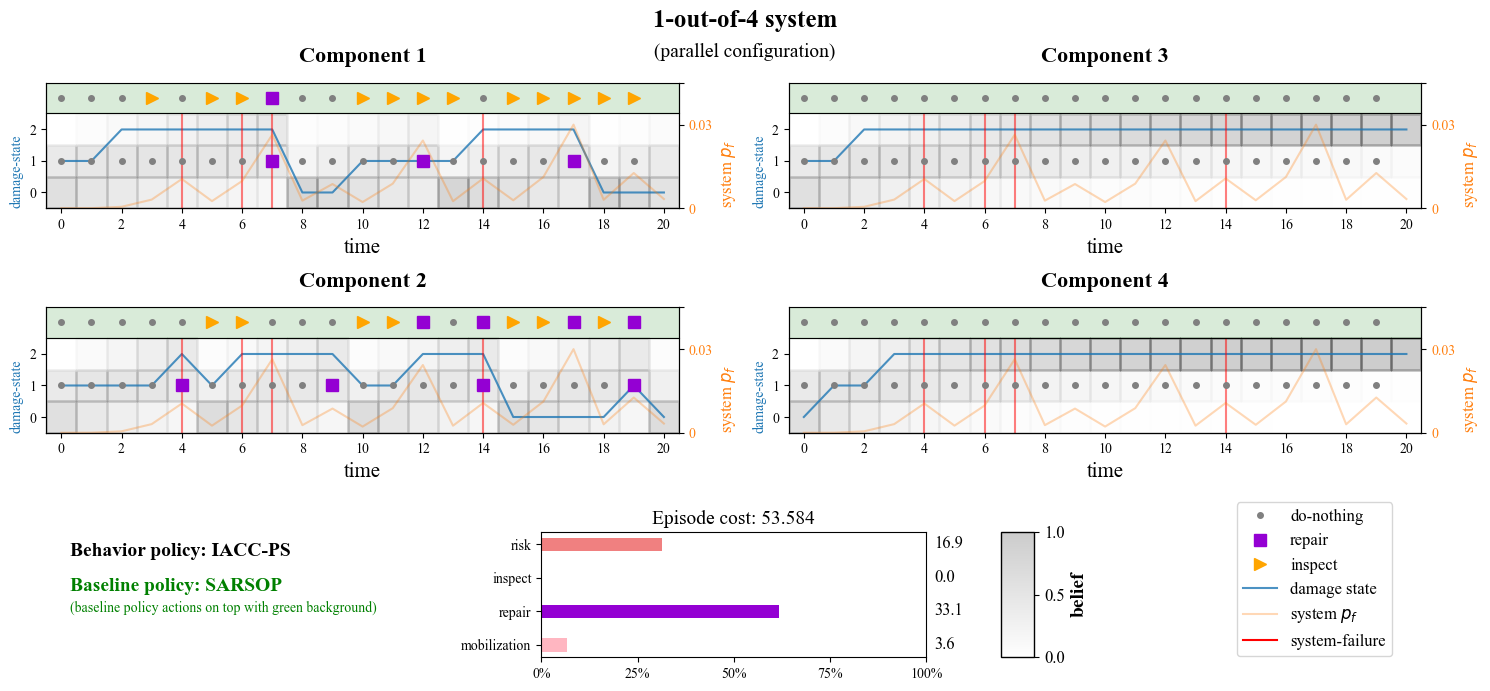

In [4]:
ROLLOUT_SEED = None  # Set to an int for reproducible rollouts
if ROLLOUT_SEED is not None:
    set_rollout_seed(ROLLOUT_SEED)

# Example 1: DRL only
# plotter = PolicyVisualizer(drl_env, drl_agent)

# Example 2: DRL and Heuristic
# plotter = PolicyVisualizer(drl_env, drl_agent, heuristic_agent)

# Example 3: DRL and SARSOP
# lookahead=True can be slow
plotter = PolicyVisualizer(
    drl_env, drl_agent, sarsop_agent, oracle_kwargs={"lookahead": False}
)

SAVE_FIG = False
if SAVE_FIG:
    setting_name = _pretty_setting_name(ENV_SETTING)
    save_fig_kwargs = {
        "fname": f"./figures/rollout_{setting_name}_{ALGORITHM}.pdf",
        "dpi": 300,
        "bbox_inches": "tight",
    }
else:
    save_fig_kwargs = None

plotter.plot(save_fig_kwargs=save_fig_kwargs)

### Plot Belief Space Plots

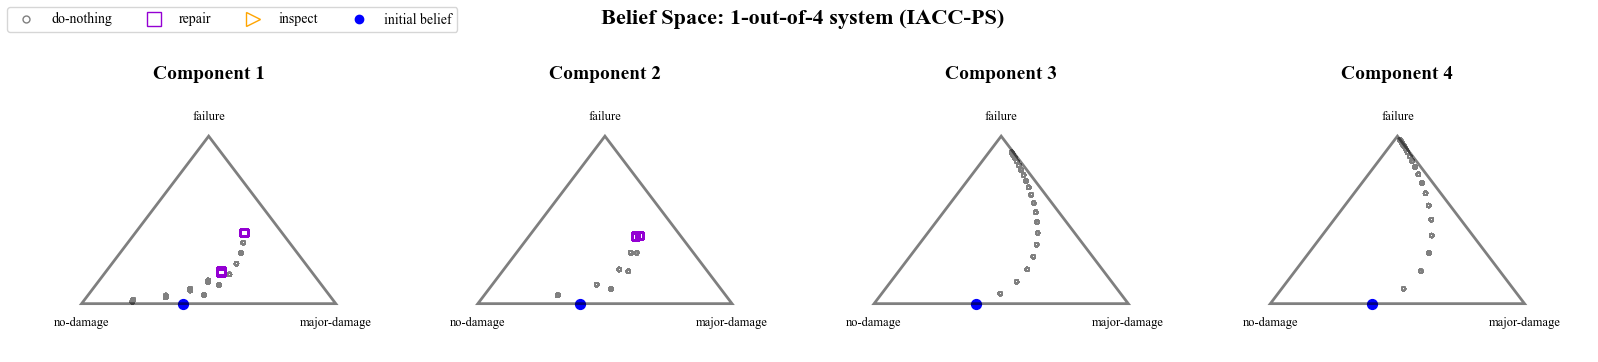

In [5]:
_ = plotter.plot_belief_space(show_actions=True, num_trajectories=100)

### Plot Action Histogram

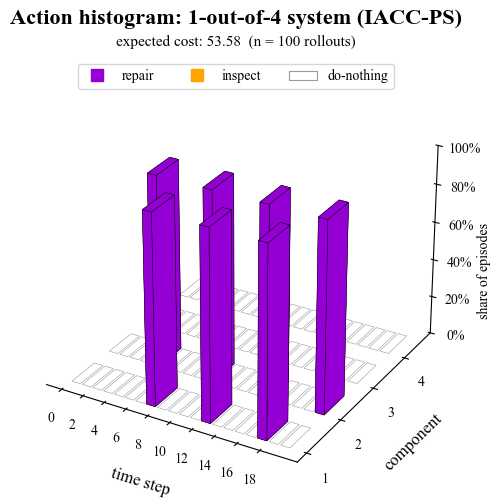

In [6]:
_ = plotter.plot_action_histogram(num_trajectories=100)  # default view="3d"

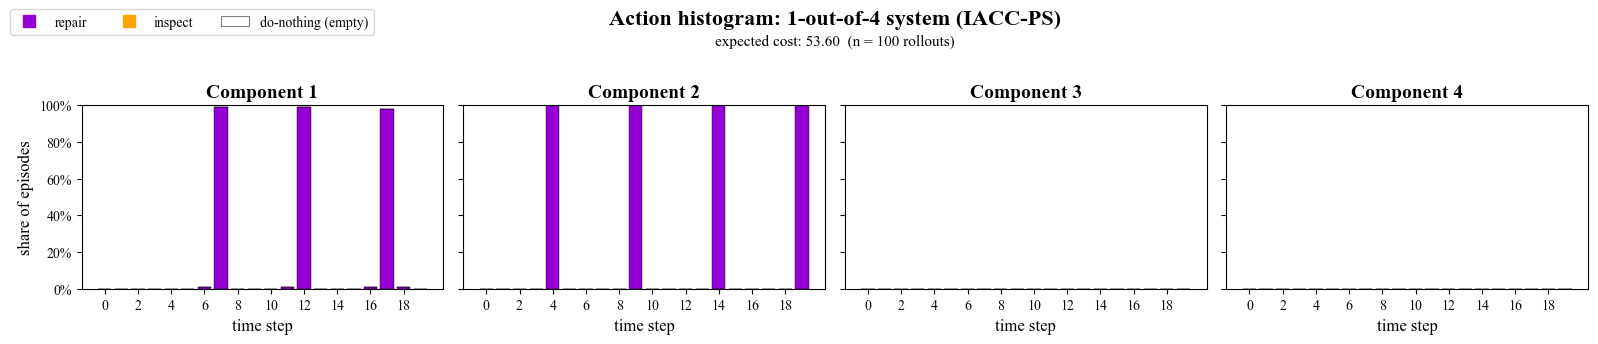

In [7]:
_ = plotter.plot_action_histogram(view="2d", num_trajectories=100)